# carGO PH — Line Plot of IoT Sensor Readings Over Time

**Week:** 7 — Line Plot of IoT Sensor Readings Over Time <br>
**Description:** Visualizes the cleaned IoT sensor data produced in Week 6 (`iot_cleaned_data.csv`). Each sensor type — GPS, Temperature, and RFID — is plotted in its own colored panel against the original sensor capture time, making patterns, trends, and anomalies easy to read.

> **Week 9** Revised (v2): Reflects generated data from v2 notebooks

## 1. Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Visualization style (template step: sns.set(style="whitegrid"))
sns.set_theme(style="whitegrid")

# One fixed color per sensor type — reused across every panel and the legend
SENSOR_COLORS = {
    "GPS":         "#1f77b4",  # blue
    "Temperature": "#d62728",  # red
    "RFID":        "#2ca02c",  # green
}

## 2. Load Cleaned Data

In [3]:
# Access preprocessed data from Homework No. 3 (Week 6 export)
df = pd.read_csv("../data/6-iot_cleaned_data_v2.csv")

# Convert timestamp columns to datetime for proper time-axis plotting
df["sensor_timestamp"]     = pd.to_datetime(df["sensor_timestamp"])
df["blockchain_timestamp"] = pd.to_datetime(df["blockchain_timestamp"])

# Sort chronologically so the lines connect points in time order
df = df.sort_values("sensor_timestamp").reset_index(drop=True)

print(f"Loaded {len(df)} records")
print("Sensor types:", df["sensor_type"].value_counts().to_dict())
print("Time range  :", df['sensor_timestamp'].min(), "→", df['sensor_timestamp'].max())
df.head()

Loaded 866 records
Sensor types: {'GPS': 400, 'Temperature': 240, 'RFID': 226}
Time range  : 2026-05-03 07:00:00 → 2026-05-07 01:00:00


,blockchain_timestamp,sensor_timestamp,rfid_tag,device_id,sensor_type,latitude,longitude,scan_status,temperature_c,is_flagged,...,package_count,vehicle_id,driver_id,shipment_status,scheduled_delivery_dt,actual_delivery_dt,delay_reason,delay_hours,scan_hour,scan_day
0,2026-06-24 13:19:44,2026-05-03 07:00:00,RFID-020,GPS255,GPS,14.667702,120.978645,NaN,NaN,False,...,49,VH-020,DR-020,Delivered,2026-05-05 14:00:00,2026-05-05 14:00:00,NaN,0.0,7,2026-05-03
1,2026-06-24 13:19:45,2026-05-03 08:00:00,RFID-020,RFD479,RFID,NaN,NaN,VERIFIED,NaN,False,...,49,VH-020,DR-020,Delivered,2026-05-05 14:00:00,2026-05-05 14:00:00,NaN,0.0,8,2026-05-03
2,2026-06-24 13:19:47,2026-05-03 09:00:00,RFID-001,TMP649,Temperature,NaN,NaN,NaN,3.2,False,...,9,VH-001,DR-001,Delivered,2026-05-05 20:00:00,2026-05-05 20:00:00,NaN,0.0,9,2026-05-03
3,2026-06-24 13:19:47,2026-05-03 09:00:00,RFID-020,GPS411,GPS,14.597148,120.976441,NaN,NaN,False,...,49,VH-020,DR-020,Delivered,2026-05-05 14:00:00,2026-05-05 14:00:00,NaN,0.0,9,2026-05-03
4,2026-06-24 13:19:46,2026-05-03 09:00:00,RFID-001,GPS926,GPS,14.644554,121.026468,NaN,NaN,False,...,9,VH-001,DR-001,Delivered,2026-05-05 20:00:00,2026-05-05 20:00:00,NaN,0.0,9,2026-05-03


## 3. Line Plot — One Panel Per Sensor Type
Three stacked panels sharing a common time axis:

| Panel | Sensor | Y-axis | What it shows |
|-------|--------|--------|----------------|
| 1 | **GPS** | Latitude (°N) | Northward movement of shipments over time |
| 2 | **Temperature** | °C | Cold-chain readings; the dashed line at 0°C separates frozen from chilled goods |
| 3 | **RFID** | Flagged scans per hour | Checkpoint anomalies aggregated hourly |

GPS and Temperature are plotted per shipment (`units="rfid_tag"`) so each line follows one shipment's own readings instead of seaborn averaging across shipments at shared timestamps. RFID status is text (`VERIFIED`/`FLAGGED`), so it is encoded into an hourly count of flagged scans to give a meaningful line. Temperature breach markers (✕) are overlaid only on Panel 2 because `temp_breach` is a concept exclusive to temperature-regulated shipments — GPS has no equivalent threshold violation, and RFID already encodes anomalies through its flagged scan count in Panel 3.

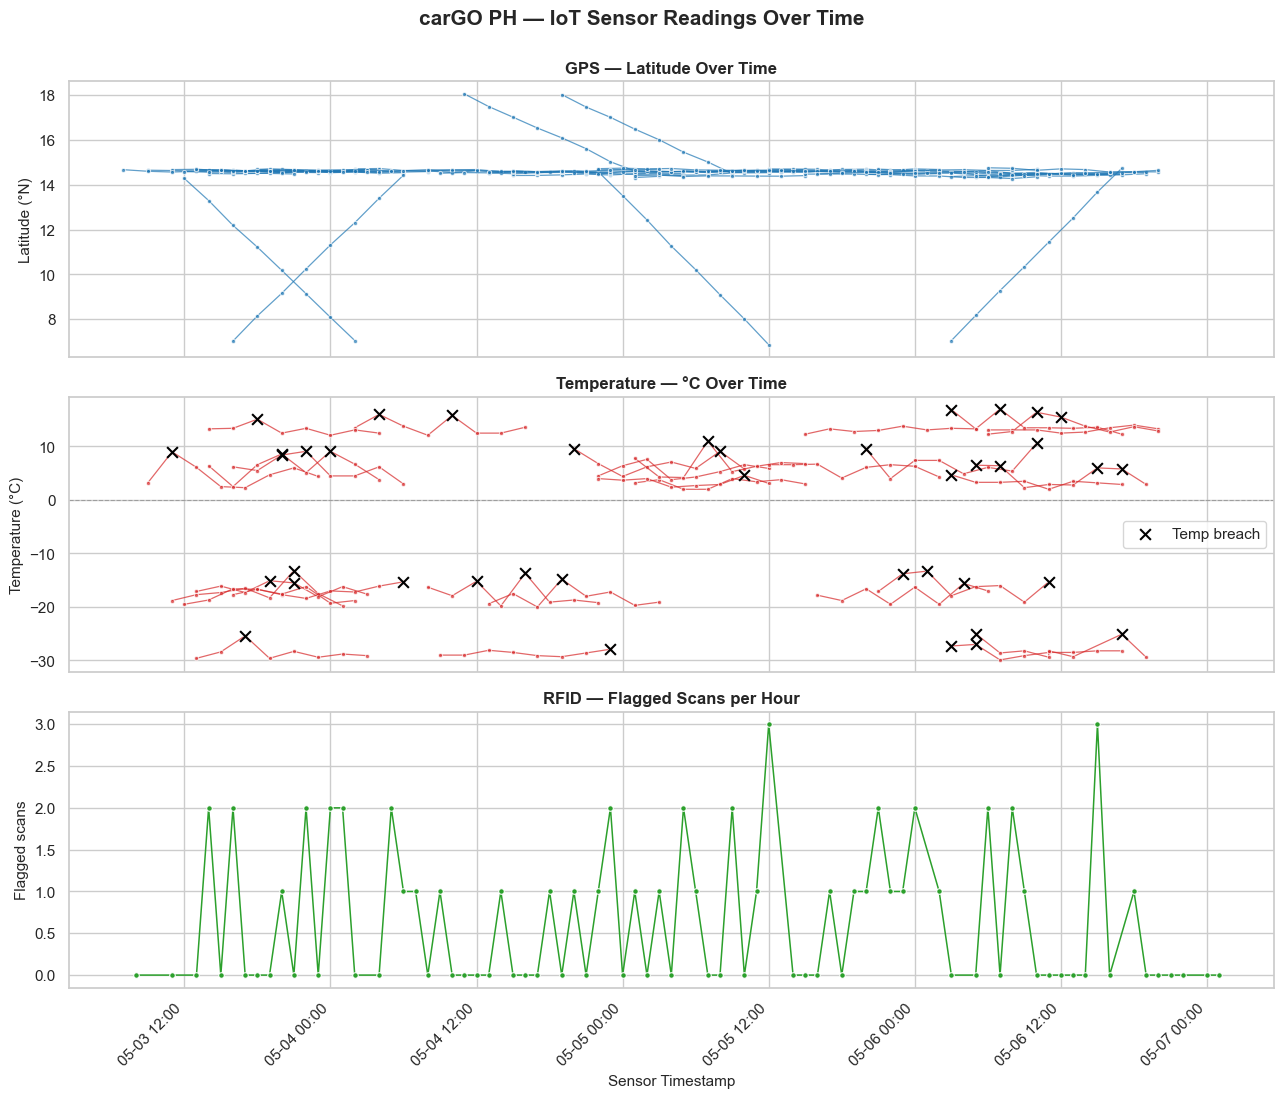

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

# ── Panel 1: GPS latitude ────────────────────────────────────
gps = df[df["sensor_type"] == "GPS"]
sns.lineplot(
    data=gps, x="sensor_timestamp", y="latitude",
    units="rfid_tag", estimator=None,           # one line per shipment, no averaging
    ax=axes[0], color=SENSOR_COLORS["GPS"],
    marker="o", markersize=3, linewidth=0.9, alpha=0.7,
)
axes[0].set_title("GPS — Latitude Over Time", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Latitude (°N)", fontsize=11)

# ── Panel 2: Temperature °C ─────────────────────────────────
temp = df[df["sensor_type"] == "Temperature"]
sns.lineplot(
    data=temp, x="sensor_timestamp", y="temperature_c",
    units="rfid_tag", estimator=None,
    ax=axes[1], color=SENSOR_COLORS["Temperature"],
    marker="o", markersize=3, linewidth=0.9, alpha=0.7,
)
axes[1].set_title("Temperature — °C Over Time", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Temperature (°C)", fontsize=11)
axes[1].axhline(0, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
# Overlay breach markers
breaches = temp[temp["temp_breach"] == True]
axes[1].scatter(breaches["sensor_timestamp"], breaches["temperature_c"],
                color="black", marker="x", s=60, zorder=5, label="Temp breach")
axes[1].legend()

# ── Panel 3: RFID flagged scans per hour ────────────────────────
rfid = df[df["sensor_type"] == "RFID"].copy()
rfid_hourly = (
    rfid.assign(hour=rfid["sensor_timestamp"].dt.floor("h"))
        .groupby("hour")["is_flagged"].sum()
        .reset_index()
)
sns.lineplot(
    data=rfid_hourly, x="hour", y="is_flagged",
    ax=axes[2], color=SENSOR_COLORS["RFID"],
    marker="o", markersize=4, linewidth=1.1,
)
axes[2].set_title("RFID — Flagged Scans per Hour", fontsize=12, fontweight="bold")
axes[2].set_ylabel("Flagged scans", fontsize=11)
axes[2].set_xlabel("Sensor Timestamp", fontsize=11)

# ── Shared x-axis formatting ────────────────────────────────
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.setp(axes[2].get_xticklabels(), rotation=45, ha="right")

fig.suptitle("carGO PH — IoT Sensor Readings Over Time",
             fontsize=15, fontweight="bold", y=0.997)
plt.tight_layout()
plt.show()

### Analysis: IoT Sensor Readings Over Time

**GPS — Latitude Over Time**
The dataset covers **50 unique shipments** tracked over approximately **4 days** (May 3–7, 2026). Most shipments operate within Metro Manila and nearby provinces, clustering between **6.9°N and 15.6°N** — a range consistent with routes across Luzon. Two shipments stand out as clear GPS anomalies: **RFID-003** (Canagatan → Mandaluyong City) and **RFID-008** (Canagatan → San Antonio), both recording latitude readings up to **~18.0°N** — far north of their expected Metro Manila delivery corridors. These are intentional test entries and would be flagged for investigation in a real operations context. Routes with minimal movement appear as near-flat lines, which is expected for short city-to-city deliveries where GPS pings are captured at regular intervals along a compact path.

**Temperature — °C Over Time**
Temperature readings span **−29.9°C to +17.0°C**, forming five distinct horizontal bands on the chart — each corresponding to a regulated goods category:
- **Cool-Chain (12.1°C → 17.0°C):** 7 breaches recorded, with readings reaching 17.0°C against a safe max of 14°C — a delta of +3°C.
- **Pharma (2.3°C → 11.0°C):** 10 breaches — the highest of any category. Readings climbed as high as 11.0°C against a safe ceiling of 8°C (+3°C deviation). Most critical to flag given pharmaceutical sensitivity.
- **Chill/Refrigerated (2.0°C → 6.5°C):** 6 breaches. Upper readings reached 6.5°C against a 4°C safe max.
- **Frozen (−20.0°C → −13.2°C):** 11 breaches — highest count overall. The warmest reading at −13.2°C represents a +2.8°C rise above the −16°C limit.
- **Deep Freeze (−29.9°C → −25.0°C):** 6 breaches. Readings approached −25.0°C against a safe max of −28°C.

The dashed line at 0°C serves as a visual divider between frozen and refrigerated cargo, making the five clusters easy to distinguish. Breach markers (✕) highlight individual readings that exceeded safe limits — Pharma and Frozen categories warrant the closest operational attention based on breach volume.

**RFID — Flagged Scans per Hour**
Across **81 observed hours**, **35 hours** recorded at least one flagged scan — roughly 43% of active hours had a checkpoint anomaly. Breakdown by spike height: **20 hours** with 1 flagged scan, **13 hours** with 2 simultaneous flags, and **2 hours** where 3 shipments were flagged in the same hour — the peak anomaly concentration in the dataset. The presence of multi-shipment spikes suggests isolated clusters of checkpoint issues rather than a single problematic shipment triggering repeated flags.

**Overall**
The dataset spans May 3–7, 2026 — roughly 4 days of active delivery operations. The most actionable findings are: 

(1) **Pharma** leads in temperature breach count at 10 events despite a narrow safe range

(2) **Frozen** goods recorded the most breaches overall (11) with the largest warm deviation

(3) **Two GPS outlier shipments (RFID-003, RFID-008)** originating from Canagatan are injected anomalies confirming the outlier detection pipeline is working

(4) **RFID flagging peaks at 3 concurrent flags per hour** — low enough to investigate individually rather than treat as noise.

## 4. (Optional) Template-Style Single Plot
For direct comparison with the code template, this cell overlays GPS and Temperature on one axis with `hue="sensor_type"`. It is kept separate because the differing scales make it harder to read — the faceted version above is the primary deliverable. RFID is excluded here since, unlike Panel 3 in Section 3 where flagged scans are aggregated into hourly counts, this overlay plots raw per-shipment readings and RFID has no equivalent raw numeric value to share the Y-axis with GPS and Temperature.

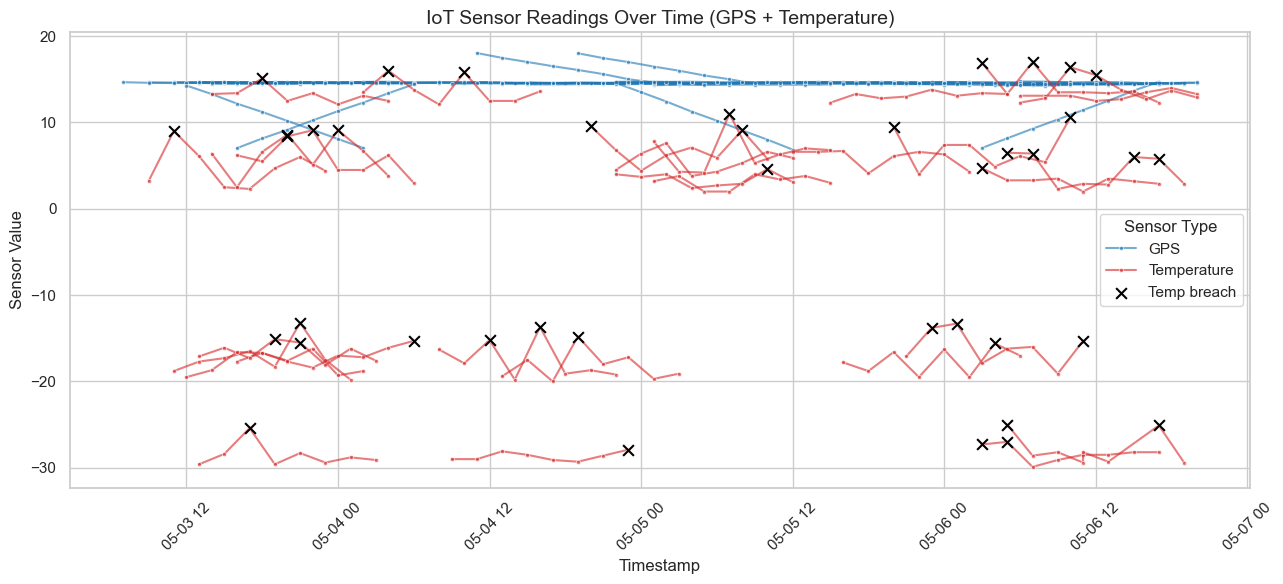

In [5]:
# Build a tidy long-form numeric_value column the way the template expects
plot_df = df.copy()
plot_df["numeric_value"] = np.where(
    plot_df["sensor_type"] == "GPS", plot_df["latitude"],
    np.where(plot_df["sensor_type"] == "Temperature", plot_df["temperature_c"], np.nan)
)
plot_df = plot_df.dropna(subset=["numeric_value"])

plt.figure(figsize=(13, 6))
sns.lineplot(
    data=plot_df, x="sensor_timestamp", y="numeric_value",
    hue="sensor_type", palette=SENSOR_COLORS,
    units="rfid_tag", estimator=None, marker="o", markersize=3, alpha=0.6,
)

# Overlay breach markers on the combined plot
breaches = plot_df[(plot_df["sensor_type"] == "Temperature") & (plot_df["temp_breach"] == True)]
plt.scatter(breaches["sensor_timestamp"], breaches["numeric_value"],
            color="black", marker="x", s=60, zorder=5, label="Temp breach")
plt.legend(title="Sensor Type")

plt.xticks(rotation=45)
plt.title("IoT Sensor Readings Over Time (GPS + Temperature)", fontsize=14)
plt.xlabel("Timestamp", fontsize=12)
plt.ylabel("Sensor Value", fontsize=12)
plt.legend(title="Sensor Type")
plt.tight_layout()
plt.show()

## 5. Save the Plot

In [6]:
fig.savefig("../data/iot_sensor_readings_over_time_v2.png", dpi=150, bbox_inches="tight")
print("Saved: data/iot_sensor_readings_over_time_v2.png")

Saved: data/iot_sensor_readings_over_time_v2.png
